# **Exploring User Behavior in UI/UX Interactions**

## **Project Description**

This project analyzes a dataset of 2,271 users to understand preferences and satisfaction across various UI/UX elements on digital platforms. Using demographic and interaction data, it explores patterns in user behavior, evaluates design components, and generates actionable insights for improving user experience.

## **Project Goals & Research Questions**

**Goals:**

* Analyze user behavior and preferences across various UI/UX elements on digital platforms.

* Identify patterns in satisfaction ratings for different design components (e.g., color schemes, layout, typography).

* Explore how demographics (age, gender) influence user experience and preferences.

* Segment users based on interaction behaviors and preferences to inform UX design decisions.

* Provide actionable recommendations for improving user experience based on insights.

**Research Questions:**

* Which UI/UX elements are most strongly associated with higher user satisfaction?

* How do user demographics (age, gender) influence UI/UX preferences?

* Are there identifiable patterns in user interactions across different platforms (e.g., social media vs websites)?

* Can we group users into segments based on their behavior and preferences? What do these segments reveal about user needs?

* Which UX components are underperforming and may need design improvements to increase engagement or satisfaction?

## **Dataset Overview**

* Number of entries: 2,271 users

* Key information included:

  *   Demographics: Name, Age, Gender

  *   Platform preferences: Twitter, YouTube, Facebook, Website

* UI/UX component evaluations: Color schemes, visual hierarchy, typography, multimedia usage, layout design

* Interaction elements: Mobile responsiveness, call-to-action buttons, form usability, feedback/error messages, loading speed, personalization, accessibility, scrolling behavior, gestures

* Data type: Quantitative ratings for each UI/UX component (e.g., 1–5 scale)

* Purpose: Enables analysis of user preferences, satisfaction, and interaction patterns to support user-centered design and usability improvements

## **Importing Packages**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
#import seaborn as sns

# Machine learning / clustering (optional for segmentation)
#from sklearn.preprocessing import StandardScaler
#from sklearn.cluster import KMeans

# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
#sns.set(style="whitegrid")

In [2]:
data = pd.read_csv(r"C:\Users\saraa\OneDrive\Desktop\Personal Projects\Exploring User Behavior in UIUX Interactions\UI UX Dataset.csv")
data.head()

,Name,Age,Gender,Platform,User_experience,Color Scheme,Visual Hierarchy,Typography,Images and Multimedia,Layout,Mobile Responsiveness,CTA (Call to Action) Buttons,Forms and Input Fields,Feedback and Error Messages,Loading Speed,Personalization,Accessibility,Animation and Transitions,Scrolling_Behavior,Gestures and Touch Controls,Search Functionality,Social_Media_Integration
0,Mohammad Rahman,21,male,Twitter,Intuitive,5,3,5,4,5,3,4,3,4,4,4,3,5,5,3,3,4
1,Fatima Khanam,45,female,Youtube,Intuitive,4,3,3,4,4,3,3,5,4,3,4,4,4,4,4,4,4
2,Ashfaq Ahmed,53,male,Facebook,Inconsistent Navigation,3,3,4,5,4,5,3,5,4,5,4,5,5,5,3,4,5
3,Nasreen Begum,63,female,Website,Adequate,4,3,3,5,5,4,5,4,4,4,5,5,5,5,4,5,4
4,Shahidul Islam,66,male,Website,Limited Menu Options,3,3,4,5,3,4,5,5,5,4,4,3,3,4,5,5,5


**Understanding the Dataset**

The dataset includes user demographics (age, gender) and platform preferences.
Each user provides ratings (1–5) for multiple UI/UX components such as layout, typography, loading speed, and accessibility.
The User_experience column represents the overall perception of the interface (e.g., intuitive).
These variables allow for analysis of how different design elements influence overall user satisfaction and behavior.

In [3]:
# Shape of the dataset
data.shape

# Column names
data.columns

# General info
data.info()

# Summary statistics
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2271 entries, 0 to 2270
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Name                          2271 non-null   object
 1   Age                           2271 non-null   int64 
 2   Gender                        2271 non-null   object
 3   Platform                      2271 non-null   object
 4   User_experience               2271 non-null   object
 5   Color Scheme                  2271 non-null   int64 
 6   Visual Hierarchy              2271 non-null   int64 
 7   Typography                    2271 non-null   int64 
 8   Images and Multimedia         2271 non-null   int64 
 9   Layout                        2271 non-null   int64 
 10  Mobile Responsiveness         2271 non-null   int64 
 11  CTA (Call to Action) Buttons  2271 non-null   int64 
 12  Forms and Input Fields        2271 non-null   int64 
 13  Feedback and Error

,Age,Color Scheme,Visual Hierarchy,Typography,Images and Multimedia,Layout,Mobile Responsiveness,CTA (Call to Action) Buttons,Forms and Input Fields,Feedback and Error Messages,Loading Speed,Personalization,Accessibility,Animation and Transitions,Scrolling_Behavior,Gestures and Touch Controls,Search Functionality,Social_Media_Integration
count,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000,2271.000000
mean,47.099956,4.120211,4.115808,3.905768,4.085425,4.211361,4.211801,4.189784,4.100396,4.100396,4.099956,4.125936,4.099075,4.094232,4.110524,4.105240,4.111405,4.088948
std,16.747152,0.706229,0.704467,0.548861,0.700355,0.607786,0.602902,0.595580,0.705270,0.706518,0.694950,0.692306,0.705144,0.711713,0.692712,0.694804,0.693206,0.711155
min,19.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
25%,33.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
50%,47.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,62.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,76.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## **Data Cleaning**

In [4]:
df = data.copy()

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

df.columns

Index(['Name', 'Age', 'Gender', 'Platform', 'User_experience', 'Color_Scheme',
       'Visual_Hierarchy', 'Typography', 'Images_and_Multimedia', 'Layout',
       'Mobile_Responsiveness', 'CTA_Call_to_Action_Buttons',
       'Forms_and_Input_Fields', 'Feedback_and_Error_Messages',
       'Loading_Speed', 'Personalization', 'Accessibility',
       'Animation_and_Transitions', 'Scrolling_Behavior',
       'Gestures_and_Touch_Controls', 'Search_Functionality',
       'Social_Media_Integration'],
      dtype='object')

In [5]:
# checking missing values
df.isnull().sum()

Name                           0
Age                            0
Gender                         0
Platform                       0
User_experience                0
Color_Scheme                   0
Visual_Hierarchy               0
Typography                     0
Images_and_Multimedia          0
Layout                         0
Mobile_Responsiveness          0
CTA_Call_to_Action_Buttons     0
Forms_and_Input_Fields         0
Feedback_and_Error_Messages    0
Loading_Speed                  0
Personalization                0
Accessibility                  0
Animation_and_Transitions      0
Scrolling_Behavior             0
Gestures_and_Touch_Controls    0
Search_Functionality           0
Social_Media_Integration       0
dtype: int64

In [6]:
# checking unique values

# Get categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Loop through and print unique values
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Name
['Mohammad Rahman' 'Fatima Khanam' 'Ashfaq Ahmed' ... 'Rik Dasgupta'
 'Chandana Dasgupta' 'Subham Sen']

Column: Gender
['male' 'female']

Column: Platform
['Twitter' 'Youtube' 'Facebook' 'Website' 'Instagram']

Column: User_experience
['Intuitive' 'Inconsistent Navigation' 'Adequate' 'Limited Menu Options'
 'Confusing' 'Well-structured' 'Engaging' 'Clear and concise' 'Efficient'
 'User-Friendly']


In [8]:
# Create a mapping dictionary to classify user experience categories

ux_map = {
    'Intuitive': 'Positive',
    'Well-structured': 'Positive',
    'Engaging': 'Positive',
    'Clear and concise': 'Positive',
    'Efficient': 'Positive',
    'User-Friendly': 'Positive',
    
    'Adequate': 'Neutral',
    
    'Inconsistent Navigation': 'Negative',
    'Limited Menu Options': 'Negative',
    'Confusing': 'Negative'
}

# Apply mapping
df['UX_Category'] = df['User_experience'].map(ux_map)

# Check results
df['UX_Category'].value_counts()

UX_Category
Positive    1349
Negative     725
Neutral      197
Name: count, dtype: int64

#### **UX Category Distribution Insights**

**Positive Experience (~59%)**
- The majority of users report a positive experience.
- This suggests that overall UI/UX design is generally effective and meets user expectations.

**Negative Experience (~32%)**
- A significant portion of users report negative experiences.
- This indicates the presence of usability issues or friction points that impact a large group of users.
- Represents a key opportunity for identifying and improving problematic UI/UX elements.

**Neutral Experience (~9%)**
- A smaller group of users report neutral experiences.
- This suggests that users tend to form clear opinions (either positive or negative) about their experience.

## **Analysis**

In [9]:
df.groupby('UX_Category').mean(numeric_only=True)

,Age,Color_Scheme,Visual_Hierarchy,Typography,Images_and_Multimedia,Layout,Mobile_Responsiveness,CTA_Call_to_Action_Buttons,Forms_and_Input_Fields,Feedback_and_Error_Messages,Loading_Speed,Personalization,Accessibility,Animation_and_Transitions,Scrolling_Behavior,Gestures_and_Touch_Controls,Search_Functionality,Social_Media_Integration
UX_Category,,,,,,,,,,,,,,,,,,
Negative,47.331034,4.147586,4.114483,3.908966,4.085517,4.208276,4.219310,4.166897,4.121379,4.089655,4.100690,4.147586,4.144828,4.068966,4.100690,4.115862,4.129655,4.115862
Neutral,45.898477,4.091371,4.096447,3.893401,4.096447,4.238579,4.192893,4.187817,3.979695,4.147208,4.091371,4.126904,4.081218,4.162437,4.076142,4.157360,4.091371,4.091371
Positive,47.151223,4.109711,4.119348,3.905856,4.083766,4.209044,4.210526,4.202372,4.106746,4.099333,4.100815,4.114159,4.077094,4.097850,4.120830,4.091920,4.104522,4.074129


### 1. Overall UX Factor Differences (Positive vs Negative)

In [10]:
# find biggest differences
positive = df[df['UX_Category'] == 'Positive'].mean(numeric_only=True)
negative = df[df['UX_Category'] == 'Negative'].mean(numeric_only=True)

difference = positive - negative

difference.sort_values(ascending=False)

CTA_Call_to_Action_Buttons     0.035476
Animation_and_Transitions      0.028885
Scrolling_Behavior             0.020141
Feedback_and_Error_Messages    0.009678
Visual_Hierarchy               0.004865
Layout                         0.000768
Loading_Speed                  0.000126
Images_and_Multimedia         -0.001751
Typography                    -0.003109
Mobile_Responsiveness         -0.008784
Forms_and_Input_Fields        -0.014634
Gestures_and_Touch_Controls   -0.023942
Search_Functionality          -0.025133
Personalization               -0.033428
Color_Scheme                  -0.037875
Social_Media_Integration      -0.041733
Accessibility                 -0.067733
Age                           -0.179811
dtype: float64

- Differences between positive and negative user experiences are relatively small across most UI/UX elements, suggesting that multiple factors collectively influence user experience rather than a single dominant feature.
- However, slight positive differences in elements like call-to-action buttons and animations indicate they may contribute marginally to better user experiences.

### 2. Top Drivers of Positive UX

In [11]:
#top 5 drivers of good UX

difference.sort_values(ascending=False).head(5)


CTA_Call_to_Action_Buttons     0.035476
Animation_and_Transitions      0.028885
Scrolling_Behavior             0.020141
Feedback_and_Error_Messages    0.009678
Visual_Hierarchy               0.004865
dtype: float64

- Call-to-action buttons, animations, and scrolling behavior show the highest positive differences, suggesting these elements play a role in enhancing user engagement and perceived usability.
- Improvements in these areas may help reinforce already positive user experiences.

### 3. Key Pain Points (Negative UX Drivers)

In [12]:
# biggest pain points (negative UX)

difference.sort_values().head(5)

Age                        -0.179811
Accessibility              -0.067733
Social_Media_Integration   -0.041733
Color_Scheme               -0.037875
Personalization            -0.033428
dtype: float64

- Accessibility, social media integration, and color scheme show the largest negative differences, indicating these areas may contribute to user frustration or dissatisfaction.
- Addressing these elements could significantly reduce negative user experiences.

### 4. UX Distribution by Platform

In [13]:
# analyze by platform

df.groupby('Platform')['UX_Category'].value_counts(normalize=True)

Platform   UX_Category
Facebook   Positive       0.613272
           Negative       0.322654
           Neutral        0.064073
Instagram  Positive       0.588496
           Negative       0.309735
           Neutral        0.101770
Twitter    Positive       0.586207
           Negative       0.351724
           Neutral        0.062069
Website    Positive       0.563193
           Negative       0.337029
           Neutral        0.099778
Youtube    Positive       0.616935
           Negative       0.280242
           Neutral        0.102823
Name: proportion, dtype: float64

- All platforms show a majority of positive experiences, but YouTube and Facebook have slightly higher positive rates, while Twitter and Website platforms show relatively higher negative experiences.
- This suggests that platform-specific design or functionality differences may influence user satisfaction.

### 5. Age and User Experience

In [14]:
# analyze by age

df.groupby('UX_Category')['Age'].mean()

UX_Category
Negative    47.331034
Neutral     45.898477
Positive    47.151223
Name: Age, dtype: float64

- Average age differences across UX categories are minimal, indicating that user experience perceptions are relatively consistent across age groups.
- This suggests that usability issues are likely design-related rather than age-specific.

### 6. Gender and User Experience

In [15]:
# gender differences

df.groupby(['Gender', 'UX_Category']).size().unstack()

UX_Category,Negative,Neutral,Positive
Gender,,,
female,374,102,684
male,351,95,665


- Both male and female users show similar distributions across UX categories, with slightly more positive experiences overall.
- This indicates that gender does not significantly influence user experience in this dataset.

### 7. Key Insights from UX Feature Differences

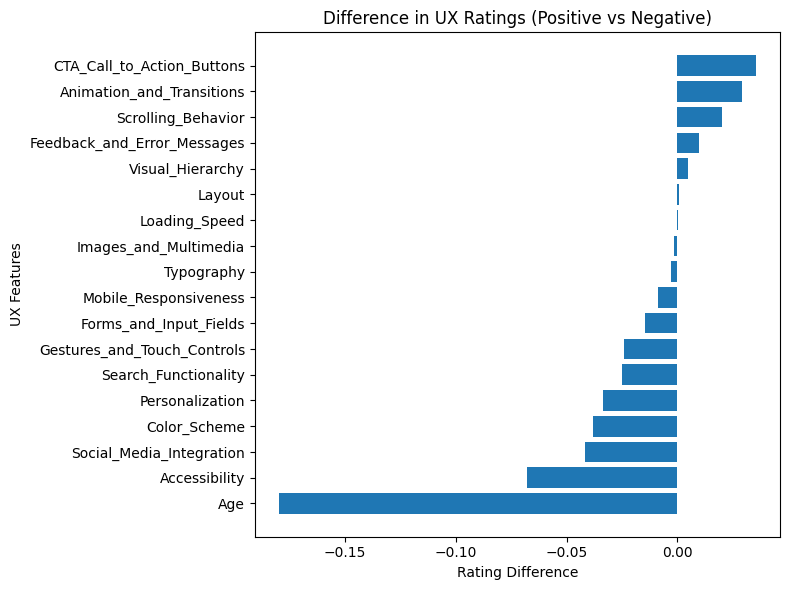

In [17]:
import matplotlib.pyplot as plt

# Sort values
diff_sorted = difference.sort_values()

# Create plot
plt.figure(figsize=(8,6))
plt.barh(diff_sorted.index, diff_sorted.values)

# Labels and title
plt.title("Difference in UX Ratings (Positive vs Negative)")
plt.xlabel("Rating Difference")
plt.ylabel("UX Features")

plt.tight_layout()
plt.show()

- Call-to-action (CTA) buttons, animations, and scrolling behavior show the strongest positive differences, indicating these elements play an important role in creating engaging and intuitive user experiences.

- Accessibility stands out as the most significant negative factor, suggesting that poor accessibility is a major contributor to user frustration and negative experiences.

- Features like social media integration, color scheme, and personalization also show noticeable negative differences, indicating these areas may not be meeting user expectations and could benefit from redesign or optimization.

- Core structural elements such as layout, visual hierarchy, and loading speed show minimal differences, suggesting they are relatively consistent across both positive and negative experiences and may not be primary differentiators.

- The large negative difference in age suggests that older users may be slightly more likely to report negative experiences, highlighting a potential need for more inclusive or user-friendly design across age groups.

- Overall, the relatively small variation across most features indicates that user experience is shaped by a combination of multiple UI/UX elements rather than a single dominant factor.

## **UX Recommendations**

**Improve Accessibility (High Priority)** <br/>
- Accessibility showed the largest negative impact on user experience.<br/>
- Enhancing accessibility features (e.g., readability, contrast, navigation support) can significantly reduce user frustration and improve overall satisfaction.

**Optimize Social Media Integration**<br/>
- Lower ratings suggest that current integrations may feel intrusive, unnecessary, or poorly implemented.<br/>
- Focus on making social features more seamless, relevant, and user-controlled.

**Refine Color Scheme and Visual Design**<br/>
- Negative differences indicate that visual design may not align with user preferences.<br/>
- Consider improving color contrast, consistency, and overall aesthetic appeal to enhance usability and engagement.

**Enhance Personalization Features**<br/>
- Personalization shows a negative impact, suggesting it may not be effectively tailored to users.<br/>
- Improve recommendation accuracy and allow users more control over personalized content.

**Strengthen Core Interaction Features (CTA, Scrolling, Animations)**<br/>
- These elements are associated with more positive user experiences.<br/>
- Continue optimizing call-to-action buttons for clarity and visibility, and ensure animations and scrolling enhance rather than distract from usability.

**Improve Input and Interaction Elements**<br/>
- Features like forms, gestures, and search functionality show slight negative trends.<br/>
- Simplifying input processes and improving responsiveness can help reduce friction in user interactions.

**Design for a Broader Age Range**<br/>
- Slight differences in age suggest that older users may experience more challenges.<br/>
- Ensure interfaces are intuitive, readable, and accessible for users across different age groups.

## **Conclusion**

- This analysis explored how various UI/UX components influence overall user experience across different digital platforms.</br>
- While the majority of users reported positive experiences, a significant portion experienced usability challenges, highlighting opportunities for improvement.</br>
- Key factors such as accessibility, social media integration, and visual design elements were identified as major contributors to negative user experiences, while features like call-to-action buttons, animations, and scrolling behavior were associated with more positive interactions.</br>
- The findings suggest that user experience is shaped by a combination of multiple design elements rather than a single factor, emphasizing the importance of a holistic approach to UX design.</br>
- Overall, this project demonstrates how data-driven insights can be used to identify usability issues and guide meaningful improvements in user-centered design.</br>